In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'AppleGothic'  # Mac 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False    # 마이너스 기호 깨짐 방지

print("pandas", pd.__version__)
print("numpy", np.__version__)
print("seaborn", sns.__version__)
print("준비 완료!")

pandas 2.2.2
numpy 1.26.4
seaborn 0.13.2
준비 완료!


In [ ]:
df = pd.read_csv('spotify-2023.csv', encoding='latin-1')
df.head()
# dataset size 측정
# 953개 행, 24개 컬럼
print(df.shape)

## 1단계 — 데이터 전처리
목표: 결측치 확인, 데이터 타입 점검 및 정제

In [ ]:
# 결측치 확인
df.isnull().sum()
# in_shazam_charts 결측치 50개, key 결측치 95개

In [ ]:
# null이 아닌 데이터 수 계산
df.count()

In [ ]:
# dataset 타입 확인
df.dtypes
# 문제 - streams 숫자처럼 보이는데 object type > 집계할 때 문제가 생긴다.

In [ ]:
# streams 컬럼이 object인 이유가 숫자가 아닌 값(쉼표, 문자 등)이 섞여 있을 수 있기 때문에
# errors 옵션을 추가해서 강제로 처리
# errors='coerce' 숫자로 변환 불가능한 값은 NaN으로 변경
df["streams"] = pd.to_numeric(df["streams"], errors='coerce')

In [ ]:
# 숫자로 변환되지 않아 결측치가 된 데이터가 있는지 확인
# 953개 중 1개 결측 - 데이터의 0.1% 정도기 때문에 행을 제거하는 것이 낫다
# 평균으로 대체 X - BTS와 신인 아티스트가 같은 데이터 안에 있기 때문에 평균이 실제 스트리밍 수를 대표할 수 없다
df["streams"].isnull().sum()

In [ ]:
# streams 컬럼 기준으로만 제거
df = df.dropna(subset=['streams'])
print(df.shape)

### 1단계 — 결과

- `streams` 컬럼이 object 타입 → `pd.to_numeric()`으로 int64 변환
- 변환 과정에서 NaN 1개 발생 (전체의 0.1%) → `dropna()`로 제거
- 최종 데이터: 952행, 24컬럼
- 결측치: `key` 95개, `in_shazam_charts` 50개 → 분석 시 그때그때 처리

## 2단계 - 아티스트 & 트랙 집계 분석

In [ ]:
# 스트리밍 Top 10 아티스트
# 지수 표기법에서 숫자 포맷 변경
pd.options.display.float_format = '{:,.0f}'.format
df.groupby("artist(s)_name")["streams"].sum().sort_values(ascending=False).head(10)

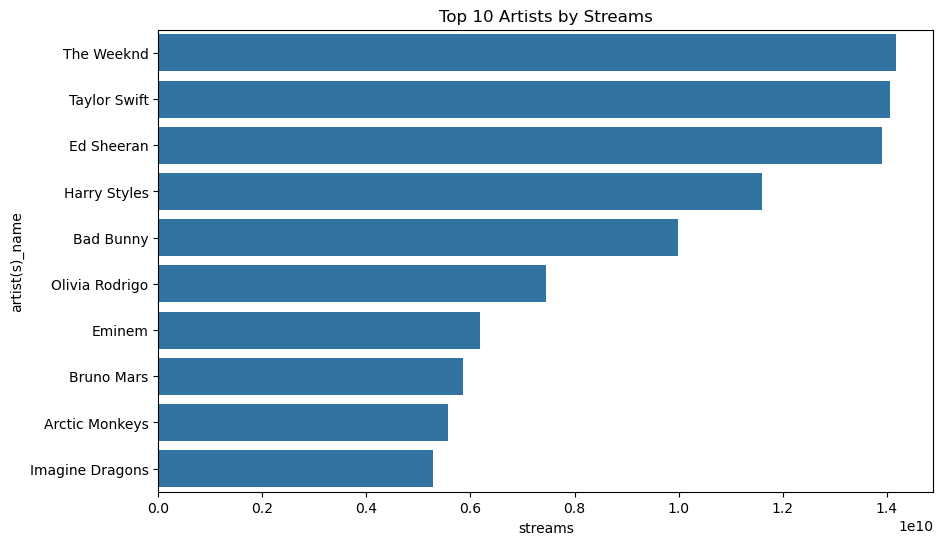

In [ ]:
# df.groupby("artist(s)_name")["streams"].sum().sort_values(ascending=False).head(10) Series(1차원)로 출력된다.
# barplot으로 시각화 하기 위해서는 DataFrame(2차원)이 필요함
# reset_index()로 index로 되어 있던 artist(s)_name을 컬럼으로 꺼내줘야한다.
top10 = df.groupby("artist(s)_name")["streams"].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=top10,x="streams",y="artist(s)_name")
plt.title("Top 10 Artists by Streams")
plt.show()

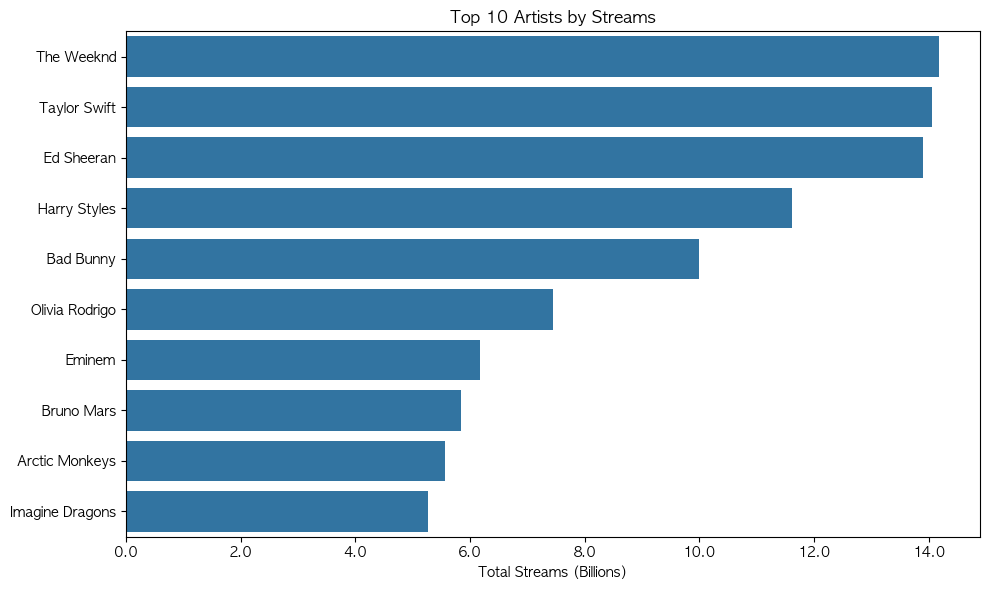

In [60]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 6))
sns.barplot(data=top10, x="streams", y="artist(s)_name")
plt.title("Top 10 Artists by Streams")
plt.xlabel("Total Streams (Billions)")
plt.ylabel("")
# plt.ticklabel_format(style="plain", axis="x")  # 지수 표기 제거
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1e9:.1f}')) #
plt.tight_layout() # 제목, 축 레이블, 눈금이 서로 겹치지 않게 자동으로 여백을 조정
plt.show()